# 🌌 Introduction to Quantum Computing with Qiskit

Welcome to your first steps in Quantum Computing! In this notebook, we will explore the basics of quantum circuits, qubits, and quantum logic gates using **Qiskit**—IBM's open-source framework for quantum computing.

---

## 🎯 Learning Objectives
By the end of this notebook, you will be able to:
1. Initialize a `QuantumCircuit`.
2. Apply basic single-qubit gates and understand their **Matrix Representations**: **X**, **Y**, **Z**, and **H**.
3. Apply multi-qubit gates like the **CNOT** gate to create entanglement.
4. Simulate quantum circuits using Qiskit Aer to see the results.

## 🛠️ Step 0: Imports and Setup
First, we need to import the necessary tools from Qiskit. If you set up your conda environment correctly, these imports should work seamlessly!

In [2]:
# Import basic standard tools
import numpy as np
import matplotlib.pyplot as plt

# Import Qiskit classes
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector

print("Libraries imported successfully! ✅")

Libraries imported successfully! ✅


## 1️⃣ Our First Quantum Circuit

In classical computing, our basic unit of information is a bit (`0` or `1`). In quantum computing, it's a **qubit**. A qubit can be `0`, `1`, or a superposition of both!

Let's create a quantum circuit with 1 qubit and 1 classical bit (to store the measurement result).

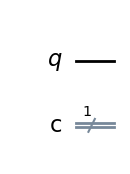

In [6]:
# Create a Quantum Circuit with 1 quantum bit (qubit) and 1 classical bit
qc1 = QuantumCircuit(1, 1)

# By default, all qubits start in the |0> state.
# Let's visualize our simple empty circuit.
qc1.draw('mpl')

## 2️⃣ The Pauli Gates (X, Y, Z)

The **X-gate** flips a qubit's state. It is the quantum equivalent of the classical NOT gate, often written as $\sigma_x$.
$$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$$

The **Y-gate** rotates the state around the Y-axis of the Bloch sphere. Notice the imaginary unit $i$.
$$Y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}$$

The **Z-gate** leaves $|0\rangle$ unchanged, but flips the phase of $|1\rangle$ to $-|1\rangle$.
$$Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$$

Let's see what the **X-Gate** does to our default state |0>.

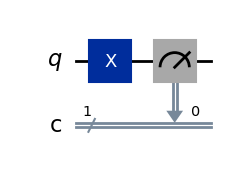

In [7]:
qc_x = QuantumCircuit(1, 1)

# Apply the X-gate to qubit 0
qc_x.x(0)

# Measure the qubit (store result of qubit 0 in classical bit 0)
qc_x.measure(0, 0)

qc_x.draw('mpl')

### Simulating the X Gate Circuit
Let's run this circuit on a simulator. We expect to measure a `1` with 100% certainty, because the starting state `|0⟩` was flipped to `|1⟩`.

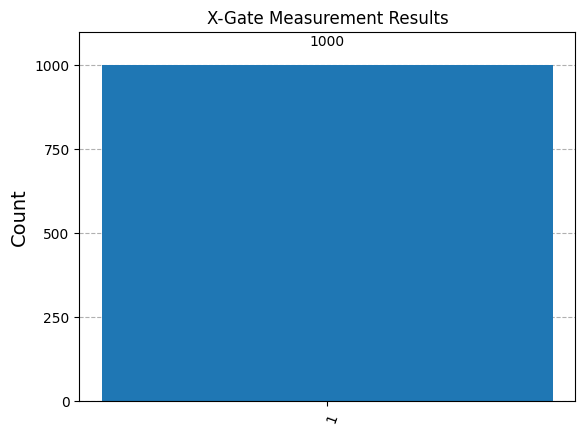

In [8]:
# Initialize the local Aer Simulator
simulator = AerSimulator()

# Transpile the circuit for the simulator
compiled_circuit = transpile(qc_x, simulator)

# Execute the circuit and get the result
job = simulator.run(compiled_circuit, shots=1000)
result = job.result()

# Get the counts (how many times we measured 0 vs 1)
counts = result.get_counts(compiled_circuit)

# Plot as a histogram
plot_histogram(counts, title="X-Gate Measurement Results")

## 3️⃣ The Hadamard Gate (Creating Superposition!)

The **Hadamard (H) gate** puts the qubit into a state of **superposition**. This means the qubit is in a combination of both `|0⟩` and `|1⟩` at the same time! When we measure it, it will "collapse" to either `0` or `1` with a 50% probability each.

Its matrix representation relies on $1/\sqrt{2}$ to ensure the probabilities equal 1:
$$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

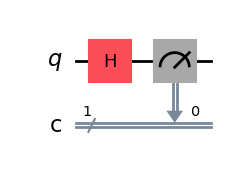

In [9]:
qc_h = QuantumCircuit(1, 1)

# Apply the H-gate to qubit 0
qc_h.h(0)

# Measure the qubit
qc_h.measure(0, 0)

qc_h.draw('mpl')

### Simulating Superposition
Let's run this 1000 times (1000 "shots") and see the statistical distribution.

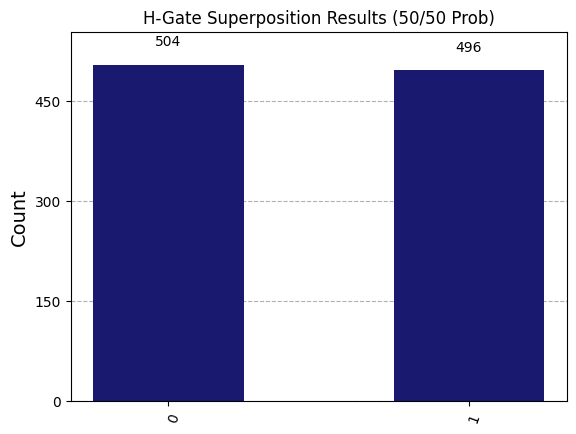

In [10]:
job_h = simulator.run(transpile(qc_h, simulator), shots=1000)
counts_h = job_h.result().get_counts()

plot_histogram(counts_h, color='midnightblue', title="H-Gate Superposition Results (50/50 Prob)")

As you can see, the outcomes are roughly 50% `0` and 50% `1`. Welcome to the core concept of Quantum Mechanics!

---

## 4️⃣ The CNOT Gate (Quantum Entanglement! 👻)

The **Controlled-NOT (CNOT) gate** involves 2 qubits. 
- It has a **Control** qubit and a **Target** qubit.
- If the Control qubit is `|1⟩`, it flips the Target qubit.
- If the Control qubit is `|0⟩`, it does nothing to the Target qubit.

Because it operates on 2 qubits, its matrix representation is a 4x4 matrix:
$$CNOT = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{pmatrix}$$

When combined with the Hadamard gate, the CNOT gate is used to create **Entanglement**. 

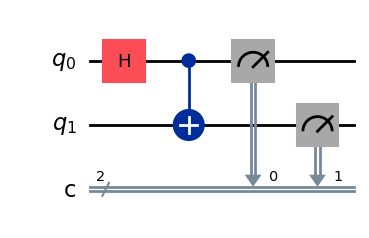

In [7]:
# Create a circuit with 2 qubits and 2 classical bits
qc_entangle = QuantumCircuit(2, 2)

# Step 1: Put Qubit 0 into superposition
qc_entangle.h(0)

# Step 2: Apply CNOT. 
# Control is Qubit 0. Target is Qubit 1.
qc_entangle.cx(0, 1)  # cx stands for Controlled-X

# Step 3: Measure both qubits
# Measure q0 into c0, and measure q1 into c1
qc_entangle.measure([0, 1], [0, 1])

qc_entangle.draw('mpl')

### Understanding the Entangled State (Bell State)
In this state (known as a Bell State or EPR Pair), the two qubits are perfectly correlated. If we measure the first qubit and find it is `0`, the second qubit will **always** instantaneously be `0`. If the first is `1`, the second will be `1`.

Let's see the results:

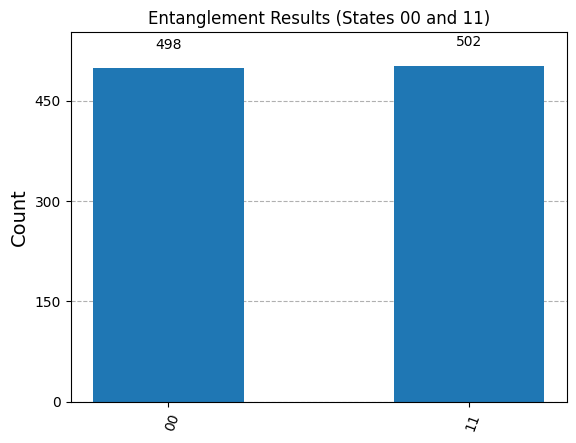

In [8]:
job_entangle = simulator.run(transpile(qc_entangle, simulator), shots=1000)
counts_entangle = job_entangle.result().get_counts()

plot_histogram(counts_entangle, title="Entanglement Results (States 00 and 11)")

---

## 5️⃣ Visualizing with the Bloch Sphere

The **Bloch Sphere** is a fantastic way to visualize the state of a single qubit. The north pole represents `|0⟩` and the south pole represents `|1⟩`. 
Let's visualize the effect of the **Y-Gate** and **Z-Gate** on a qubit using `plot_bloch_multivector`!

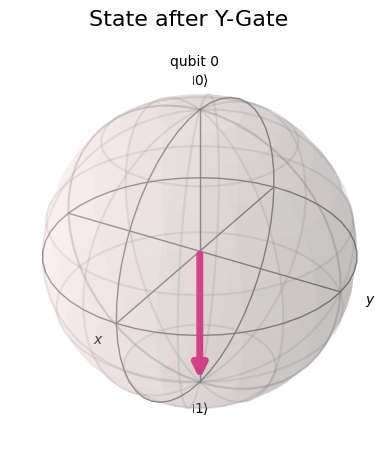

In [3]:
# Create a circuit and apply Y gate
qc_y = QuantumCircuit(1)
qc_y.y(0)

# Get the statevector of the qubit
state_y = Statevector(qc_y)

# Plot the state on the Bloch Sphere
plot_bloch_multivector(state_y, title="State after Y-Gate")

You can see how the state rotated to the south pole (`|1⟩`), but with a different complex phase compared to the X-gate.

Now let's try the **Z-Gate**. Remember, the Z-gate only affects the phase of `|1⟩`. If we apply it to `|0⟩`, nothing visibly changes. Let's apply an H-gate first to put it in superposition (on the equator of the Bloch sphere), then apply the Z-gate.

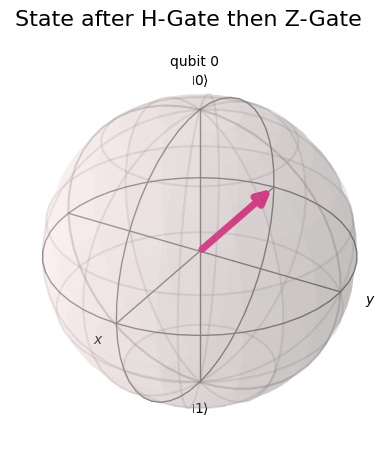

In [4]:
qc_z = QuantumCircuit(1)
qc_z.h(0)  # Superposition first
qc_z.z(0)  # Then Z-gate

state_z = Statevector(qc_z)
plot_bloch_multivector(state_z, title="State after H-Gate then Z-Gate")

Notice how the vector is now pointing to the back of the sphere (the `|-⟩` state) instead of the front (the `|+⟩` state). This is the phase flip caused by the Z-gate!

---

## 6️⃣ More Multi-Qubit Gates: SWAP and Toffoli

The **SWAP gate** simply swaps the states of two qubits.
The **Toffoli gate (CCX)** is a Controlled-Controlled-NOT gate. It has TWO control qubits and ONE target qubit. It only flips the target if BOTH controls are `|1⟩`. It's the quantum equivalent of a classical AND gate.

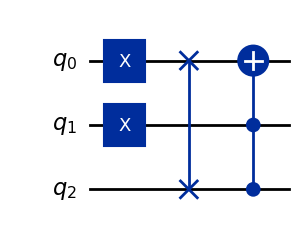

In [5]:
qc_multi = QuantumCircuit(3)

# Apply X gate to qubit 0 and 1 so they are in state |1>
qc_multi.x(0)
qc_multi.x(1)

# Apply SWAP between 0 and 2. Now Qubit 2 and 1 are exactly |1>, and Qubit 0 is |0>
qc_multi.swap(0, 2)

# Apply Toffoli (CCX) controlling on 1 and 2, targeting 0.
# Since 1 and 2 are |1>, qubit 0 will be flipped to |1>!
qc_multi.ccx(1, 2, 0)

qc_multi.draw('mpl')

Notice that we only measure states `00` and `11` (with ~50% probability each). We **never** measure `01` or `10`. The qubits behave as one interconnected system regardless of distance. Albert Einstein famously called this *"spooky action at a distance"*.

---
## 🎉 Summary
In this notebook, you successfully:
- Set up a Qiskit Simulation.
- Flipped a bit with an **X-Gate**.
- Created Superposition with an **H-Gate**.
- Entangled two particles using a **CNOT-Gate**.

- Visualized states on the **Bloch Sphere**.
- Explored the **SWAP** and **Toffoli** gates.

This is just the beginning of your Quantum Computing journey. Happy coding!